In [4]:
import pandas as pd

df = pd.read_csv("/content/campus_energy.csv")

df.head()

,Date,Building,Units_Consumed,Cost_Per_Unit,Total_Cost
0,01-01-2026,Hostel,313,8,2504
1,02-01-2026,Classroom,246,8,1968
2,03-01-2026,Office,133,8,1064
3,04-01-2026,Hostel,186,8,1488
4,05-01-2026,Library,334,8,2672


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            100 non-null    object
 1   Building        100 non-null    object
 2   Units_Consumed  100 non-null    int64 
 3   Cost_Per_Unit   100 non-null    int64 
 4   Total_Cost      100 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 4.0+ KB


In [6]:
df.isnull().sum()

,0
Date,0
Building,0
Units_Consumed,0
Cost_Per_Unit,0
Total_Cost,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

0


In [17]:
df.drop_duplicates(inplace=True)

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            100 non-null    datetime64[ns]
 1   Building        100 non-null    object        
 2   Units_Consumed  100 non-null    int64         
 3   Cost_Per_Unit   100 non-null    int64         
 4   Total_Cost      100 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 4.0+ KB


In [18]:
total_units = df['Units_Consumed'].sum()
print("Total Units Consumed:", total_units)

Total Units Consumed: 32106


In [19]:
total_cost = df['Total_Cost'].sum()
print("Total Cost:", total_cost)

Total Cost: 256848


In [20]:
building_usage = df.groupby('Building')['Units_Consumed'].sum()
print(building_usage)

Building
Classroom    5952
Hostel       8703
Lab          4320
Library      5704
Office       7427
Name: Units_Consumed, dtype: int64


In [21]:
highest_building = df.groupby('Building')['Units_Consumed'].sum().idxmax()
print("Highest Energy Consuming Building:", highest_building)

Highest Energy Consuming Building: Hostel


In [22]:
average_units = df['Units_Consumed'].mean()
print("Average Units Consumed:", average_units)

Average Units Consumed: 321.06


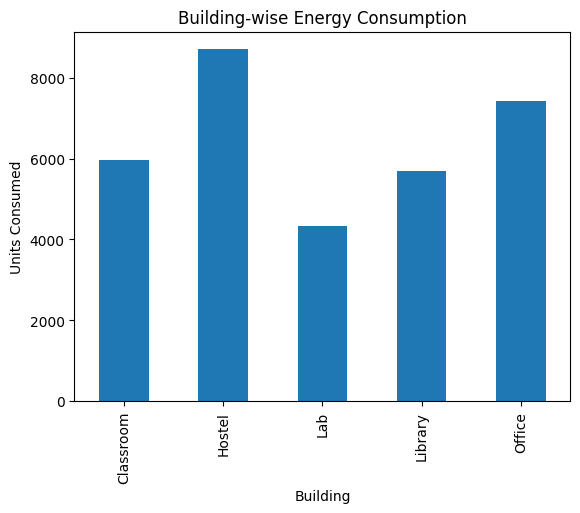

In [23]:
import matplotlib.pyplot as plt
building_usage = df.groupby('Building')['Units_Consumed'].sum()

building_usage.plot(kind='bar')
plt.xlabel("Building")
plt.ylabel("Units Consumed")
plt.title("Building-wise Energy Consumption")
plt.show()


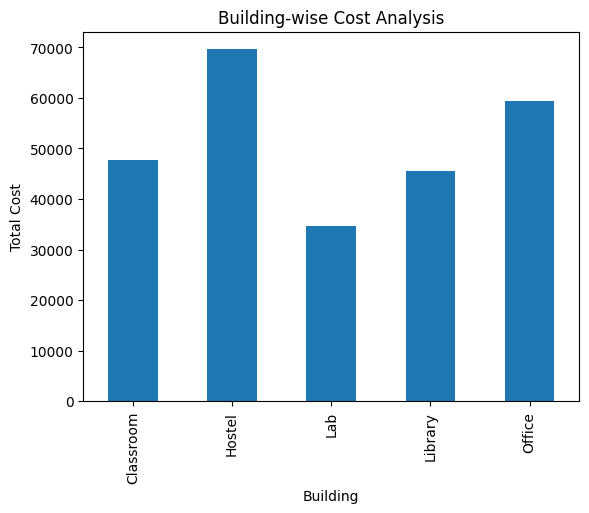

In [24]:
building_cost = df.groupby('Building')['Total_Cost'].sum()

building_cost.plot(kind='bar')
plt.xlabel("Building")
plt.ylabel("Total Cost")
plt.title("Building-wise Cost Analysis")
plt.show()

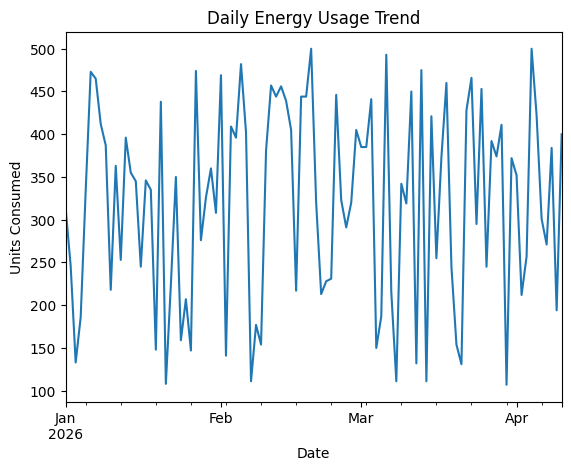

In [25]:
daily_usage = df.groupby('Date')['Units_Consumed'].sum()

daily_usage.plot()
plt.xlabel("Date")
plt.ylabel("Units Consumed")
plt.title("Daily Energy Usage Trend")
plt.show()

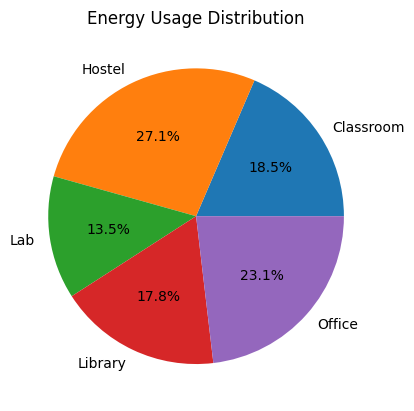

In [26]:
building_usage.plot(kind='pie', autopct='%1.1f%%')
plt.title("Energy Usage Distribution")
plt.ylabel("")
plt.show()


Monthly Energy Consumption
Month
1    9330
2    9705
3    9778
4    3293
Name: Units_Consumed, dtype: int64


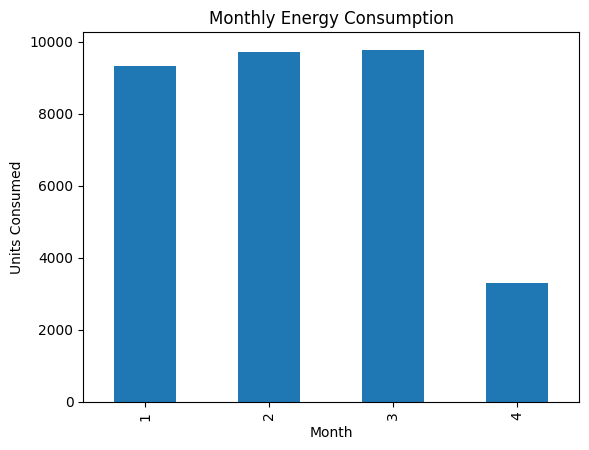


Peak Usage Day
Date              2026-02-19 00:00:00
Building                      Library
Units_Consumed                    500
Cost_Per_Unit                       8
Total_Cost                       4000
Month                               2
Name: 49, dtype: object

Lowest Usage Day
Date              2026-03-30 00:00:00
Building                    Classroom
Units_Consumed                    107
Cost_Per_Unit                       8
Total_Cost                        856
Month                               3
Name: 88, dtype: object

Energy Wastage Records
         Date   Building  Units_Consumed  Cost_Per_Unit  Total_Cost  Month
5  2026-01-06     Hostel             473              8        3784      1
6  2026-01-07     Hostel             465              8        3720      1
7  2026-01-08     Office             412              8        3296      1
19 2026-01-20     Hostel             438              8        3504      1
26 2026-01-27     Office             474              8        

In [30]:
#Create Month column
df['Month'] = df['Date'].dt.month

# Monthly energy consumption
monthly_usage = df.groupby('Month')['Units_Consumed'].sum()
print("\nMonthly Energy Consumption")
print(monthly_usage)

# Monthly graph
monthly_usage.plot(kind='bar')
plt.xlabel("Month")
plt.ylabel("Units Consumed")
plt.title("Monthly Energy Consumption")
plt.show()

# Peak usage day
peak_day = df.loc[df['Units_Consumed'].idxmax()]
print("\nPeak Usage Day")
print(peak_day)

# Lowest usage day
low_day = df.loc[df['Units_Consumed'].idxmin()]
print("\nLowest Usage Day")
print(low_day)

# Energy wastage detection
wastage = df[df['Units_Consumed'] > 400]
print("\nEnergy Wastage Records")
print(wastage)